In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gymnasium as gym
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch

from highway.scripts.environment import get_env, ConfigType, SHARED_CORE_CONFIG
from highway.scripts.run import eval_agent, run_one_episode

from copy import deepcopy
from scipy import stats

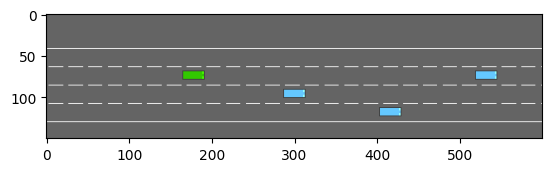

In [3]:
env = get_env(seed=1, config_type=ConfigType.SHARED_CORE)
# Show the environment
plt.imshow(env.render())
plt.show()

## Evaluation setup

In [4]:
eval_seeds = list(range(30))

In [5]:
def plot_losses(losses, nb_smoothen=500, title="Losses during training"):
    x_smoothen = np.arange(len(losses) - nb_smoothen + 1) + nb_smoothen // 2
    smooth_losses = np.convolve(losses, np.ones(nb_smoothen)/nb_smoothen, mode='valid')
    plt.plot(losses)
    plt.plot(x_smoothen, smooth_losses, color='red')
    plt.title(title)
    plt.xlabel("Frames")
    plt.ylabel("Loss")
    plt.show()

def plot_train_rewards_lengths(rewards, lengths, nb_smoothen=10, title="Rewards and episode lengths during training"):
    x_smoothen = np.arange(len(rewards) - nb_smoothen + 1) + nb_smoothen // 2
    smooth_rewards = np.convolve(rewards, np.ones(nb_smoothen)/nb_smoothen, mode='valid')
    smooth_lengths = np.convolve(lengths, np.ones(nb_smoothen)/nb_smoothen, mode='valid')
    rewards_per_frame = rewards / lengths
    smooth_rewards_per_frame = np.convolve(rewards_per_frame, np.ones(nb_smoothen)/nb_smoothen, mode='valid')

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(title)
    axs[0].plot(rewards)
    axs[0].plot(x_smoothen, smooth_rewards, color='red')
    axs[0].set_title(f"Rewards during training")
    axs[0].set_xlabel("Evaluation steps")
    axs[0].set_ylabel("Mean reward")
    axs[0].set_ylim(0, 30)

    axs[1].plot(lengths)
    axs[1].plot(x_smoothen, smooth_lengths, color='red')
    axs[1].set_title(f"Episode lengths during training")
    axs[1].set_xlabel("Evaluation steps")
    axs[1].set_ylabel("Mean episode length")
    axs[1].set_ylim(0, 30)

    axs[2].plot(rewards_per_frame)
    axs[2].plot(x_smoothen, smooth_rewards_per_frame, color='red')
    axs[2].set_title(f"Episode reward per frame during training")
    axs[2].set_xlabel("Evaluation steps")
    axs[2].set_ylabel("Mean reward per frame")
    axs[2].set_ylim(None, 1)
    plt.tight_layout()
    plt.show()

In [28]:
def plot_rewards_lengths(rewards, lengths, title=None):
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(title)
    axs[0].hist(rewards, bins=20, color='blue', alpha=0.7, density=True)
    axs[0].set_title("Distribution of Rewards")
    axs[0].set_xlabel("Reward")
    axs[0].set_ylabel("Frequency")
    axs[0].set_ylim(0, 1)

    axs[1].hist(lengths, bins=20, color='orange', alpha=0.7, density=True)
    axs[1].set_title("Distribution of Episode Lengths")
    axs[1].set_xlabel("Episode Length")
    axs[1].set_ylabel("Frequency")
    axs[1].set_ylim(0, 1)

    axs[2].scatter(lengths, rewards, alpha=0.8, marker='+')
    axs[2].plot([0, 30], [0, 30], color='red', linestyle='--', alpha=0.5)
    min_1 = - 0.02
    min_30 = 29 * (1.5/2.2) - 29*0.02
    axs[2].plot([1, 30], [min_1, min_30], color='blue', linestyle='--', alpha=0.5)
    axs[2].set_title("Reward vs Episode Length")
    axs[2].set_xlabel("Episode Length")
    axs[2].set_ylabel("Reward")
    axs[2].set_xlim(0, 31)
    axs[2].set_ylim(0, 31)
    plt.tight_layout()
    plt.show()

In [7]:
def compute_confidence_interval(values, confidence=0.95):
    n = len(values)
    if n < 2:
        raise ValueError("At least 2 values are required to compute statistics.")

    arr = np.array(values)
    mean = np.mean(arr)
    std_dev = np.std(arr, ddof=1)          # sample std deviation (unbiased)
    std_error = std_dev / np.sqrt(n)       # standard error of the mean

    # t critical value for confidence% CI (two-tailed), degrees of freedom = n - 1
    alpha = (1 - confidence) / 2
    t_critical = stats.t.ppf(1 - alpha, df=n - 1)
    margin_of_error = t_critical * std_error

    return {
        "n": n,
        "mean": mean,
        "std_dev": std_dev,
        "std_error": std_error,
        "t_critical": t_critical,
        "margin_of_error": margin_of_error,
        "ci_lower": mean - margin_of_error,
        "ci_upper": mean + margin_of_error,
    }

## Baseline

### Random Agent

In [8]:
from highway.models.random_agent.random_agent import RandomAgent

agent = RandomAgent(env.observation_space, env.action_space)

rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [01:35<00:00,  3.20s/ep]


In [9]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 9.15 ± 2.29 (95% CI: [6.87, 11.44])
Length: 12.27 ± 3.05 (95% CI: [9.22, 15.32])


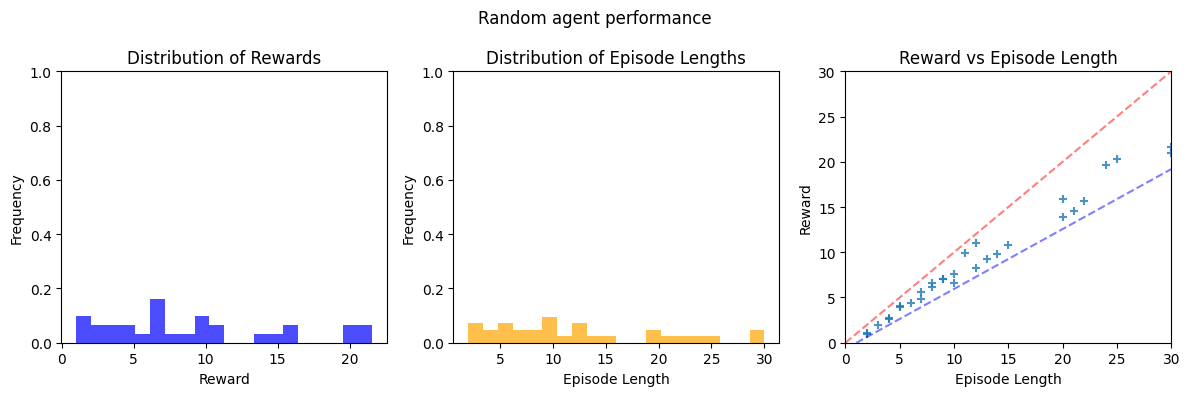

In [10]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

### Idle agent

In [11]:
from highway.models.idle_agent.idle_agent import IdleAgent

agent = IdleAgent(env.observation_space, env.action_space)

rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [02:25<00:00,  4.84s/ep]


In [12]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 14.67 ± 2.61 (95% CI: [12.07, 17.28])
Length: 19.17 ± 3.19 (95% CI: [15.98, 22.35])


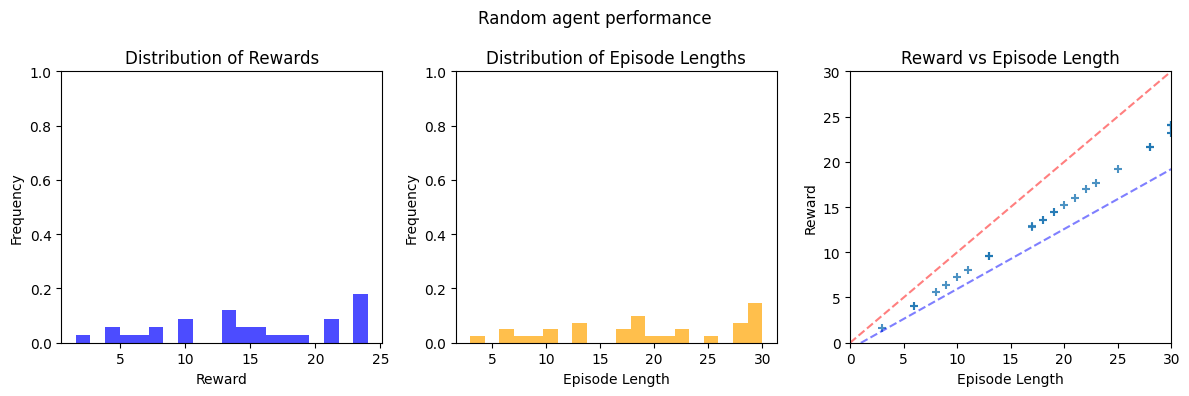

In [13]:
plot_rewards_lengths(rewards, lengths, title="Random agent performance")

## DQN Agent

In [14]:
from highway.models.dqn.dqn import DQN

action_space = env.action_space
observation_space = env.observation_space

gamma = 0.9
batch_size = 64
buffer_capacity = 10_000
update_target_every = 200

epsilon_start = 0.95
decrease_epsilon_factor = 50
epsilon_min = 0.05

learning_rate = 5e-4

arguments = (action_space,
            observation_space,
            gamma,
            batch_size,
            buffer_capacity,
            update_target_every, 
            epsilon_start, 
            decrease_epsilon_factor, 
            epsilon_min,
            learning_rate,
        )

dqn_base_agent = DQN(*arguments)

In [15]:
def get_training_paths(date_str:str):
    best_model_path = os.path.join("model_weights", "dqn", f"dqn_best_model_{date_str}.pth")

    losses = np.load(os.path.join("results", "dqn", "loss", f"dqn_losses_{date_str}.npy"))
    rewards = np.load(os.path.join("results", "dqn", "reward", f"dqn_rewards_{date_str}.npy"))
    lengths = np.load(os.path.join("results", "dqn", "length", f"dqn_lengths_{date_str}.npy"))
    
    ep_paths = [path for path in os.listdir(os.path.join("model_weights", "dqn")) if date_str in path and "_ep" in path]
    ep_paths = sorted(ep_paths, key=lambda x: int(x.split("_")[-2][2:]))

    return best_model_path, losses, rewards, lengths, ep_paths

### Identical environment for training and evaluation

In [16]:
date_str = "20260410_152850"

best_model_path, losses, train_rewards, train_lengths, ep_paths = get_training_paths(date_str)

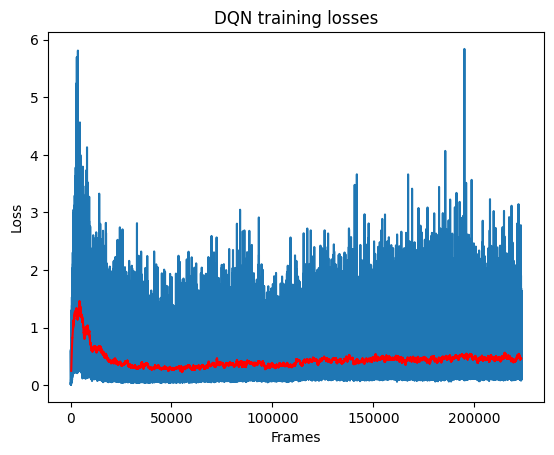

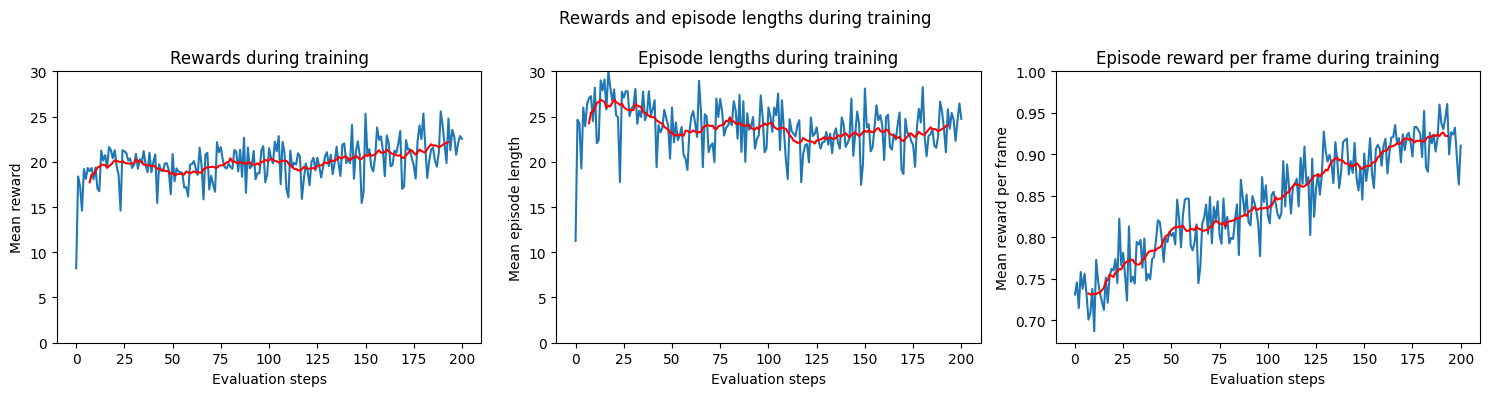

In [17]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

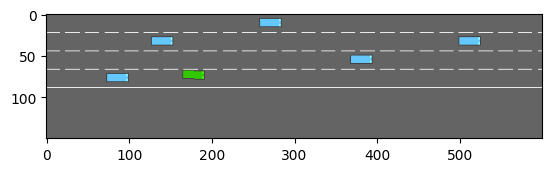

Episode reward=29.54, length=30


In [18]:
agent = deepcopy(dqn_base_agent)
agent.q_net.load_state_dict(torch.load(best_model_path))

reward, length = run_one_episode(env, agent, display=True)

In [19]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [03:03<00:00,  6.11s/ep]


In [20]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 21.69 ± 2.99 (95% CI: [18.70, 24.68])
Length: 23.83 ± 3.15 (95% CI: [20.69, 26.98])


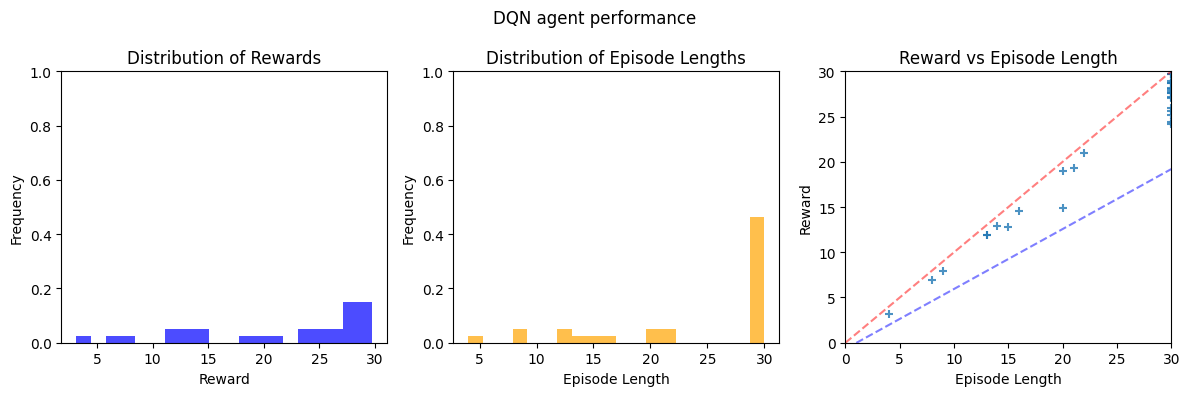

In [21]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

### Different environment between training and evaluation

In [22]:
date_str = "20260410_192141"

best_model_path, losses, train_rewards, train_lengths, ep_paths = get_training_paths(date_str)

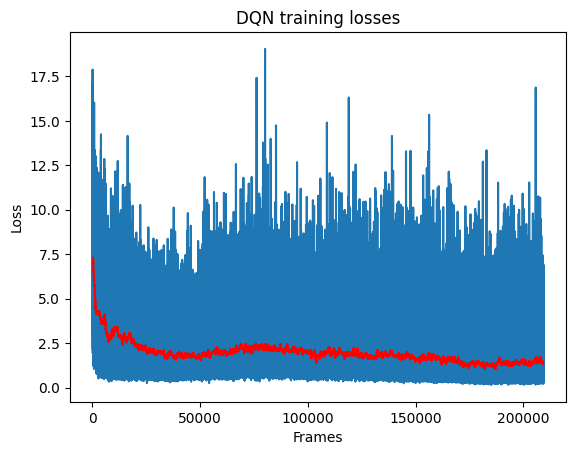

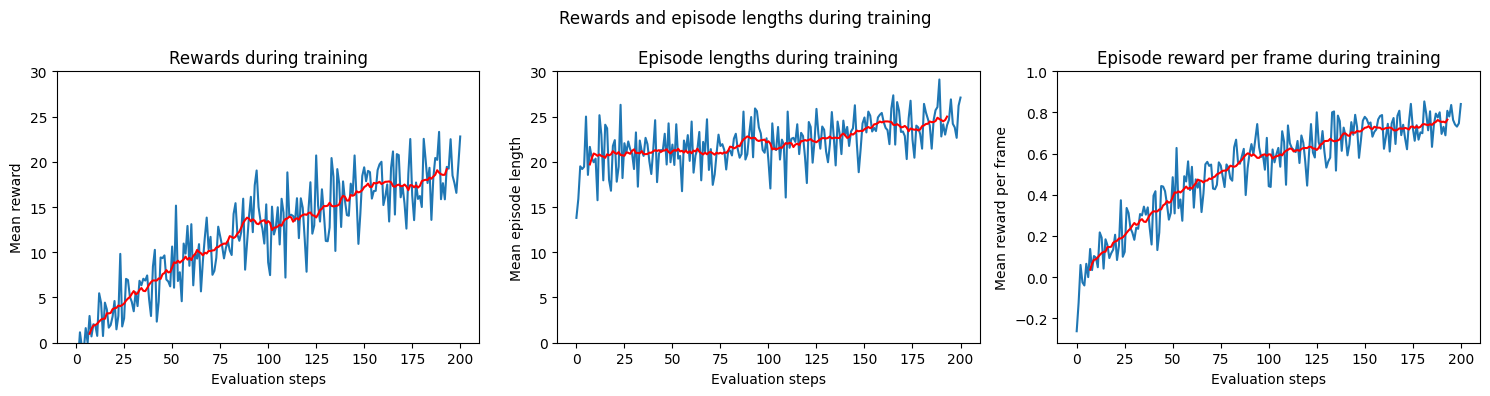

In [23]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

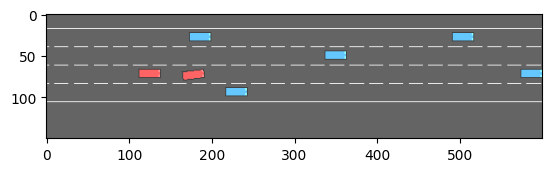

Episode reward=23.95, length=25


In [24]:
agent = deepcopy(dqn_base_agent)
agent.q_net.load_state_dict(torch.load(best_model_path))

reward, length = run_one_episode(env, agent, display=True)

In [25]:
rewards, lengths = eval_agent(env, agent, seeds=eval_seeds, show_progress=True)

Evaluating: 100%|██████████| 30/30 [02:53<00:00,  5.77s/ep]


In [26]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

Reward: 21.40 ± 3.40 (95% CI: [18.00, 24.80])
Length: 22.63 ± 3.39 (95% CI: [19.24, 26.03])


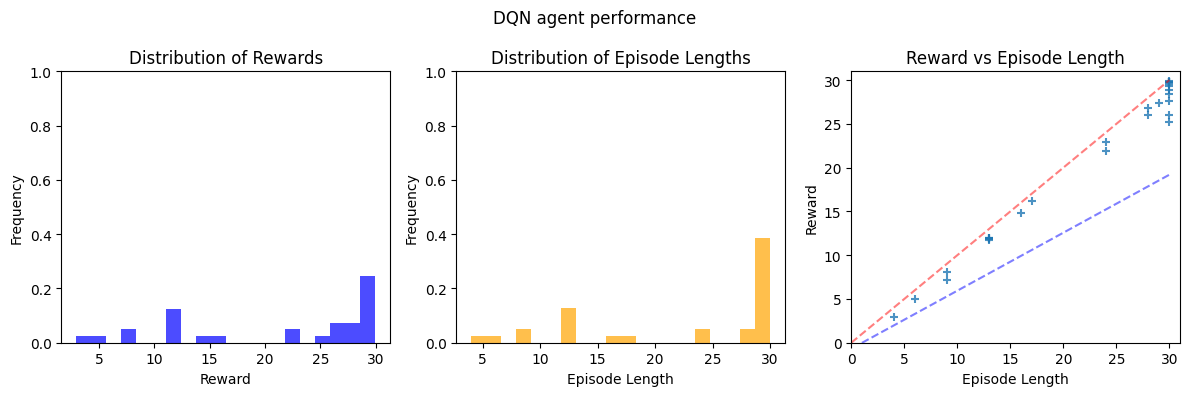

In [29]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

# DQN (Stable Baselines)

In [ ]:
from highway.models.dqn_sb3.dqn_sb3 import DQN_SB3
import pandas as pd

best_model_path = os.path.join("logs", "dqn_sb3", "best_model", "best_model.zip")

dqn_sb3_agent = DQN_SB3.load(best_model_path, env=env)

dqn_progress = pd.read_csv(os.path.join("logs", "dqn_sb3", "progress.csv"))
dqn_train_monitor = pd.read_csv(os.path.join("logs", "dqn_sb3", "train_monitor.csv"), comment="#")

losses = dqn_progress["train/loss"].values
rewards = dqn_train_monitor["r"].values
lengths = dqn_train_monitor["l"].values

In [ ]:
plot_losses(losses, nb_smoothen=500, title="DQN training losses")
plot_train_rewards_lengths(train_rewards, train_lengths, nb_smoothen=15)

In [ ]:
reward, length = run_one_episode(env, dqn_sb3_agent, display=True)

In [ ]:
rewards, lengths = eval_agent(env, dqn_sb3_agent, seeds=eval_seeds, show_progress=True)

In [ ]:
stats_rewards = compute_confidence_interval(rewards)
stats_lengths = compute_confidence_interval(lengths)

print(f"Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

In [ ]:
plot_rewards_lengths(rewards, lengths, title="DQN agent performance")

# PPO (Stable Baselines)

In [ ]:
from highway.models.ppo_sb3.ppo_sb3 import PPO_SB3
import pandas as pd

best_model_path = os.path.join("logs", "ppo_sb3", "checkpoints", "ppo_model_130000.zip")

ppo_sb3_agent = PPO_SB3.load(best_model_path, env=env)

ppo_progress = pd.read_csv(os.path.join("logs", "ppo_sb3", "progress.csv"))
ppo_train_monitor = pd.read_csv(os.path.join("logs", "ppo_sb3", "train_monitor.csv"), comment="#")

losses = ppo_progress["train/loss"].values
rewards = ppo_train_monitor["r"].values
lengths = ppo_train_monitor["l"].values

In [ ]:
# --- PPO training curves from Monitor (same style as DQN) ---
ppo_train_rewards = rewards
ppo_train_lengths = lengths

plot_train_rewards_lengths(
    ppo_train_rewards,
    ppo_train_lengths,
    nb_smoothen=10,
    title="PPO training (Monitor): rewards/lengths",
 )

In [ ]:
# --- PPO-specific SB3 metrics from progress.csv ---
def plot_ppo_progress_metrics(progress_df, title="PPO training metrics (SB3 progress.csv)"):
    # Prefer timesteps on x-axis when available
    if "time/total_timesteps" in progress_df.columns:
        x = progress_df["time/total_timesteps"].to_numpy()
        x_label = "Timesteps"
    else:
        x = np.arange(len(progress_df))
        x_label = "Steps (rows in progress.csv)"

    metric_specs = [
        ("rollout/ep_rew_mean", "rollout/ep_rew_mean"),
        ("rollout/ep_len_mean", "rollout/ep_len_mean"),
        ("train/approx_kl", "train/approx_kl"),
        ("train/clip_fraction", "train/clip_fraction"),
        ("train/entropy_loss", "train/entropy_loss"),
        ("train/value_loss", "train/value_loss"),
        ("train/explained_variance", "train/explained_variance"),
        ("train/policy_gradient_loss", "train/policy_gradient_loss"),
        ("train/loss", "train/loss"),
        ("train/learning_rate", "train/learning_rate"),
    ]

    present = []
    for col, label in metric_specs:
        if col not in progress_df.columns:
            continue
        series = progress_df[col]
        if hasattr(series, "dropna") and series.dropna().empty:
            continue
        present.append((col, label))

    if not present:
        print("No PPO metrics found in progress.csv (columns differ from expected SB3 PPO logs).")
        return

    ncols = 2
    nrows = int(np.ceil(len(present) / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows), sharex=True)
    axs = np.array(axs).reshape(-1)

    # Rolling window for smoothing (adapt to run length)
    window = max(1, len(progress_df) // 50)

    for ax, (col, label) in zip(axs, present):
        y = progress_df[col].to_numpy()
        ax.plot(x, y, alpha=0.8)
        # Smoothed curve (robust to NaNs)
        try:
            y_smooth = pd.Series(y).rolling(window=window, min_periods=1).mean().to_numpy()
            ax.plot(x, y_smooth, color="red", linewidth=2)
        except Exception:
            pass
        ax.set_title(label)
        ax.set_xlabel(x_label)
        ax.grid(True, alpha=0.2)

    for ax in axs[len(present):]:
        ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_ppo_progress_metrics(ppo_progress)

In [ ]:
# --- PPO evaluation (same evaluation flow as DQN) ---
ppo_eval_rewards, ppo_eval_lengths = eval_agent(
    env,
    ppo_sb3_agent,
    seeds=eval_seeds,
    show_progress=True,
 )

stats_rewards = compute_confidence_interval(ppo_eval_rewards)
stats_lengths = compute_confidence_interval(ppo_eval_lengths)

print(f"PPO Reward: {stats_rewards['mean']:.2f} ± {stats_rewards['margin_of_error']:.2f} (95% CI: [{stats_rewards['ci_lower']:.2f}, {stats_rewards['ci_upper']:.2f}])")
print(f"PPO Length: {stats_lengths['mean']:.2f} ± {stats_lengths['margin_of_error']:.2f} (95% CI: [{stats_lengths['ci_lower']:.2f}, {stats_lengths['ci_upper']:.2f}])")

plot_rewards_lengths(ppo_eval_rewards, ppo_eval_lengths, title="PPO agent performance")